### Human in the loop in Langgraph workflow

Usecase:

Interruption for human feedback in the graph which is bind to custom tools.

In [1]:
#importing libraries

import os
from dotenv import load_dotenv

from langchain.chat_models import init_chat_model
from langchain_tavily import TavilySearch
from langchain.tools import tool

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langgraph.checkpoint.memory import MemorySaver

from typing import List, Annotated
from typing_extensions import TypedDict

from pprint import pprint

load_dotenv()

d:\Agentic_AI\agenticenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\Agentic_AI\agenticenv\Lib\site-packages\langchain_tavily\tavily_research.py:97: UserWarning: Field name "output_schema" in "TavilyResearch" shadows an attribute in parent "BaseTool"
  class TavilyResearch(BaseTool):  # type: ignore[override, override]
d:\Agentic_AI\agenticenv\Lib\site-packages\langchain_tavily\tavily_research.py:97: UserWarning: Field name "stream" in "TavilyResearch" shadows an attribute in parent "BaseTool"
  class TavilyResearch(BaseTool):  # type: ignore[override, override]


True

In [2]:
#defining custom tools

@tool
def multiply(x:int, y:int)->int:
    "this function performs multiplication operation on given values and returns output"
    return x*y

tavily_tool = TavilySearch(max_results=3)



### Human in the loop with LLM


In [3]:
my_tools = [tavily_tool, multiply]

model_tools = init_chat_model(model="groq:llama-3.1-8b-instant").bind_tools(my_tools)
model_tools

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000021F0CB60770>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000021F0CBC42F0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input sho

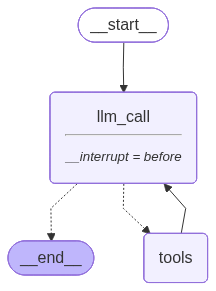

In [4]:
#defining schema and workflow with hitl

class State(TypedDict):
    messages : Annotated[List, add_messages]

def llm_call(state:State):
    response = model_tools.invoke(state['messages']) 
    return {"messages": [response]}   

tools = ToolNode(my_tools)


graph_builder = StateGraph(State)

graph_builder.add_node("llm_call", llm_call)
graph_builder.add_node("tools", tools)

graph_builder.add_edge(START, "llm_call")
graph_builder.add_conditional_edges("llm_call", tools_condition)
graph_builder.add_edge("tools", "llm_call")

graph = graph_builder.compile(interrupt_before=["llm_call"], checkpointer=MemorySaver())
graph



In [5]:
#invoking graph
query="give me most recent news on agentic ai"
config={"configurable":{"thread_id":"user_model"}}

for event in graph.stream({"messages": query},stream_mode="values", config=config):
    event['messages'][-1].pretty_print()



================================ Human Message =================================

give me most recent news on agentic ai


In [6]:
[state for state in graph.get_state_history(config=config)]

[StateSnapshot(values={'messages': [HumanMessage(content='give me most recent news on agentic ai', additional_kwargs={}, response_metadata={}, id='02f87db5-e315-4a0c-a1bc-b70ab5abbe78')]}, next=('llm_call',), config={'configurable': {'thread_id': 'user_model', 'checkpoint_ns': '', 'checkpoint_id': '1f0ea34a-f332-6388-8000-e5fced52f949'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-01-05T12:47:24.704858+00:00', parent_config={'configurable': {'thread_id': 'user_model', 'checkpoint_ns': '', 'checkpoint_id': '1f0ea34a-f329-620e-bfff-3799f5e3ae38'}}, tasks=(PregelTask(id='aacbbcad-d013-a82f-3b68-f9af7739302b', name='llm_call', path=('__pregel_pull', 'llm_call'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'messages': []}, next=('__start__',), config={'configurable': {'thread_id': 'user_model', 'checkpoint_ns': '', 'checkpoint_id': '1f0ea34a-f329-620e-bfff-3799f5e3ae38'}}, metadata={'source': 'input', 'step': -1,

In [7]:
graph.get_state(config=config).next

('llm_call',)

In [8]:
for event in graph.stream(None,stream_mode="values", config=config):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

give me most recent news on agentic ai
================================== Ai Message ==================================
Tool Calls:
  tavily_search (ncqsec3qq)
 Call ID: ncqsec3qq
  Args:
    query: agentic AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "agentic AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.washingtonpost.com/opinions/2026/01/05/agentic-artificial-intelligence-ai-tech/", "title": "Opinion | Action-taking AI is speeding ahead. Let’s get some guardrails up. - The Washington Post", "score": 0.99963164, "published_date": "Mon, 05 Jan 2026 10:45:53 GMT", "content": "What happens if an AI makes a decision in your name, and it gets it wrong? And what if companies or government agencies begin designing systems that assume everyone has

### Human in the loop using Agent

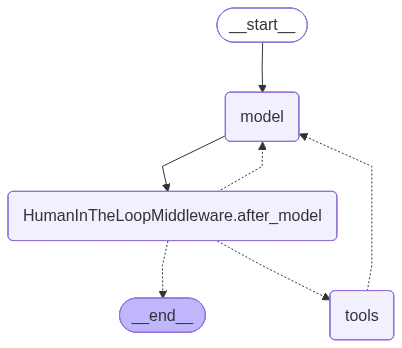

In [44]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware

human_feedback = HumanInTheLoopMiddleware(interrupt_on={"tavily_tool": {"allowed_decisions":["approve", "edit"]}, "multiply":{"allowed_decisions":["approve", "edit"]}})
agent = create_agent(
    model=init_chat_model(model="groq:llama-3.1-8b-instant"),
    tools=my_tools,
    middleware=[human_feedback],
    checkpointer=MemorySaver()
)

agent

In [ ]:
#agent.invoke({"messages":{"role":"user", "content":"get few lines on latest news about agentic ai and then mutiply 2 with 3"}}, config={"configurable":{"thread_id":"user_agent"}})

{'messages': [HumanMessage(content='get few lines on latest news about agentic ai and then mutiply 2 with 3', additional_kwargs={}, response_metadata={}, id='bd9082b1-c974-4dd7-98f0-2bbacddc5e8c'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'kjr66b9xq', 'function': {'arguments': '{"query":"latest news on agentic AI","search_depth":"advanced","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}, {'id': 'shmsb8yzr', 'function': {'arguments': '{"query":"agentic AI recent developments","search_depth":"advanced","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}, {'id': 'rr4tfpspy', 'function': {'arguments': '{"query":"agentic AI breakthroughs","search_depth":"advanced","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}, {'id': 'kgyq45d9x', 'function': {'arguments': '{"x":2,"y":3}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 116, 'prompt_tokens': 1769, 'total_tokens': 1885, 'c

In [45]:
from langgraph.types import Command

config={"configurable":{"thread_id":"user_agent"}}
result=agent.invoke({"messages":{"role":"user", "content":"get few lines on latest news about agentic ai and then mutiply 2 with 3"}},config=config)
if '__interrupt__' in result['messages']:
    print("yes")
    res = agent.invoke(Command(resume={"decisions":[{"type":'approve'}]}), config=config)
   
